# Implementacion de K-means para agrupar acciones

**Objetivo:** crear una tabla aleatoria de acciones usando tres variables (`Precio`, `Dividendos` y `Volatilidad`), aplicar clustering con K-means y justificar el numero de clusters con el metodo del codo y el coeficiente de silhouette.

En este ejercicio las variables significan:

- `Precio`: precio de la accion.
- `Dividendos`: rendimiento anual por dividendos en porcentaje.
- `Volatilidad`: volatilidad anual en porcentaje.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 50)


## 1. Tabla aleatoria de acciones

Se generan 36 acciones simuladas. Aunque los valores son aleatorios, se crean con tres comportamientos de mercado para que el agrupamiento tenga sentido:

- Acciones de crecimiento: precio alto, dividendos bajos y volatilidad alta.
- Acciones balanceadas: valores intermedios.
- Acciones defensivas: precio bajo, dividendos altos y volatilidad baja.

La columna usada para identificar cada dato es `Accion`; las variables del modelo son solamente `Precio`, `Dividendos` y `Volatilidad`.


In [2]:
rng = np.random.default_rng(42)

acciones = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "NFLX", "AMD", "MA", "V", "COST",
    "JPM", "BAC", "WMT", "DIS", "ORCL", "IBM", "CAT", "NKE", "MCD", "GE", "F", "GM",
    "KO", "PEP", "PG", "JNJ", "PFE", "XOM", "CVX", "VZ", "T", "ECOPETROL", "BHP", "RIO",
]

perfiles = [
    {
        "nombre": "Crecimiento",
        "precio_media": 185,
        "precio_sd": 25,
        "div_media": 0.8,
        "div_sd": 0.35,
        "vol_media": 47,
        "vol_sd": 5,
    },
    {
        "nombre": "Balanceada",
        "precio_media": 85,
        "precio_sd": 14,
        "div_media": 3.0,
        "div_sd": 0.45,
        "vol_media": 25,
        "vol_sd": 3.5,
    },
    {
        "nombre": "Dividendos",
        "precio_media": 35,
        "precio_sd": 7,
        "div_media": 6.4,
        "div_sd": 0.7,
        "vol_media": 13,
        "vol_sd": 2.2,
    },
]

filas = []
for perfil in perfiles:
    for _ in range(12):
        filas.append(
            {
                "Precio": round(float(np.clip(rng.normal(perfil["precio_media"], perfil["precio_sd"]), 5, 260)), 2),
                "Dividendos": round(float(np.clip(rng.normal(perfil["div_media"], perfil["div_sd"]), 0, 9)), 2),
                "Volatilidad": round(float(np.clip(rng.normal(perfil["vol_media"], perfil["vol_sd"]), 5, 65)), 2),
            }
        )

df = pd.DataFrame(filas)
df.insert(0, "Accion", acciones)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

display(df)


,Accion,Precio,Dividendos,Volatilidad
0,RIO,33.56,5.73,12.25
1,BAC,94.11,3.33,26.90
2,PG,39.38,6.18,14.00
3,CVX,39.66,6.33,12.07
4,ORCL,94.50,3.03,26.01
5,VZ,34.44,5.22,9.82
6,GE,93.21,3.32,27.78
7,JPM,83.40,2.62,22.11
8,AMD,174.29,0.68,49.66
9,IBM,93.84,2.34,23.88


## 2. Escalamiento de variables

K-means usa distancias. Por eso las variables deben estandarizarse antes de entrenar el modelo. Si no se escala, `Precio` puede dominar el calculo porque tiene una magnitud mayor que `Dividendos` y `Volatilidad`.


In [3]:
variables = ["Precio", "Dividendos", "Volatilidad"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[variables])

X_scaled_df = pd.DataFrame(X_scaled, columns=[f"{col}_std" for col in variables])
display(X_scaled_df.head())


,Precio_std,Dividendos_std,Volatilidad_std
0,-1.042363,1.071445,-1.121253
1,-0.121360,0.010681,-0.112642
2,-0.953837,1.270338,-1.000771
3,-0.949578,1.336636,-1.133646
4,-0.115427,-0.121914,-0.173916


## 3. Metodo del codo para elegir K

El metodo del codo compara la inercia o WCSS (*Within-Cluster Sum of Squares*) para diferentes valores de K. Se busca el punto donde la reduccion de la inercia deja de ser tan fuerte. Ese punto es una buena opcion para el numero de clusters.


,K,Inercia
0,1,108.0000
1,2,25.4728
2,3,3.9043
3,4,2.7098
4,5,2.3173
5,6,1.9472
6,7,1.6202
7,8,1.3528
8,9,1.1416
9,10,0.9719


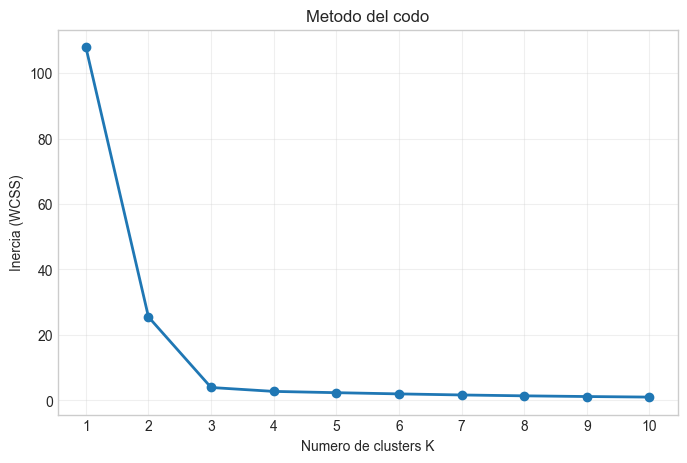

In [4]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    modelo.fit(X_scaled)
    inertias.append(modelo.inertia_)

inercia_df = pd.DataFrame({"K": list(k_values), "Inercia": inertias})
display(inercia_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o", linewidth=2)
plt.xticks(list(k_values))
plt.xlabel("Numero de clusters K")
plt.ylabel("Inercia (WCSS)")
plt.title("Metodo del codo")
plt.grid(alpha=0.3)
plt.show()


## 4. Coeficiente de silhouette

El coeficiente de silhouette mide que tan bien queda cada dato dentro de su cluster comparado con otros clusters. Sus valores van aproximadamente de -1 a 1:

- Cercano a 1: buena separacion.
- Cercano a 0: el dato esta cerca de una frontera entre clusters.
- Negativo: posible asignacion incorrecta.

Para silhouette se evalua desde K = 2 porque con K = 1 no existe comparacion entre clusters.


,K,Coeficiente silhouette
0,2,0.6805
1,3,0.7936
2,4,0.6827
3,5,0.5263
4,6,0.3709
5,7,0.3358
6,8,0.3556
7,9,0.3637
8,10,0.3531


K con mayor silhouette: 3


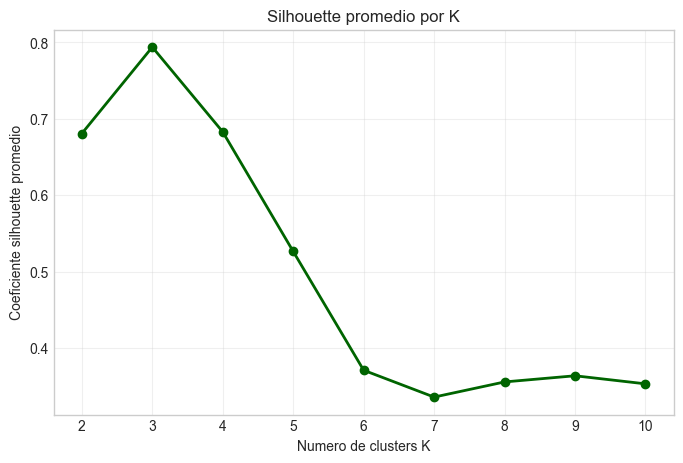

In [5]:
silhouette_rows = []

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = modelo.fit_predict(X_scaled)
    silhouette_rows.append(
        {
            "K": k,
            "Coeficiente silhouette": silhouette_score(X_scaled, labels),
        }
    )

silhouette_df = pd.DataFrame(silhouette_rows)
display(silhouette_df.round(4))

best_k_silhouette = int(
    silhouette_df.loc[silhouette_df["Coeficiente silhouette"].idxmax(), "K"]
)
print(f"K con mayor silhouette: {best_k_silhouette}")

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_df["K"],
    silhouette_df["Coeficiente silhouette"],
    marker="o",
    linewidth=2,
    color="darkgreen",
)
plt.xticks(silhouette_df["K"])
plt.xlabel("Numero de clusters K")
plt.ylabel("Coeficiente silhouette promedio")
plt.title("Silhouette promedio por K")
plt.grid(alpha=0.3)
plt.show()


## 5. Aplicacion de K-means con K elegido

A partir del grafico del codo y la comparacion de silhouette, se usa **K = 3**. En este caso, K = 3 representa tres grupos interpretables de acciones: crecimiento, balanceadas y defensivas/dividendos.


In [11]:
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, random_state=72, n_init=20)
df_cluster = df.copy()
df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)

centros = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=variables,
)
centros.insert(0, "Cluster", range(k_optimo))


def interpretar_cluster(row):
    if row["Volatilidad"] >= 35 and row["Dividendos"] <= 2:
        return "Crecimiento: precio alto, bajo dividendo y mayor volatilidad"
    if row["Volatilidad"] <= 18 and row["Dividendos"] >= 5:
        return "Defensivas: alto dividendo y baja volatilidad"
    return "Balanceadas: valores intermedios"


centros["Interpretacion"] = centros.apply(interpretar_cluster, axis=1)

display(centros.round({"Precio": 2, "Dividendos": 2, "Volatilidad": 2}))
display(df_cluster.sort_values(["Cluster", "Accion"]).reset_index(drop=True))


,Cluster,Precio,Dividendos,Volatilidad,Interpretacion
0,0,32.87,6.22,12.80,Defensivas: alto dividendo y baja volatilidad
1,1,187.48,0.82,47.40,"Crecimiento: precio alto, bajo dividendo y may..."
2,2,85.92,2.88,25.41,Balanceadas: valores intermedios


,Accion,Precio,Dividendos,Volatilidad,Cluster
0,BHP,32.51,6.92,10.95,0
1,CVX,39.66,6.33,12.07,0
2,ECOPETROL,28.66,6.14,15.86,0
3,JNJ,30.37,6.15,12.16,0
4,KO,28.56,6.75,13.31,0
5,PEP,39.83,6.10,13.35,0
6,PFE,26.63,6.74,11.97,0
7,PG,39.38,6.18,14.00,0
8,RIO,33.56,5.73,12.25,0
9,T,25.74,5.70,13.88,0


## 6. Resumen por cluster

La siguiente tabla resume el numero de acciones y el promedio de cada variable en cada cluster. Esta tabla es util para sustentar que significa cada grupo.


In [7]:
resumen = (
    df_cluster.groupby("Cluster")[variables]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

display(resumen)


Precio                         Dividendos                    \
         count    mean     min     max      count  mean   min   max   
Cluster                                                               
0           12  187.48  163.52  238.54         12  0.82  0.12  1.23   
1           12   32.87   25.74   39.83         12  6.22  5.22  6.92   
2           12   85.92   61.44  105.93         12  2.88  2.34  3.39   

        Volatilidad                       
              count   mean    min    max  
Cluster                                   
0                12  47.40  40.49  52.64  
1                12  12.80   9.82  15.86  
2                12  25.41  21.03  28.39

## 7. Visualizacion de clusters

El primer grafico muestra `Precio` contra `Dividendos`, usando el color para el cluster y el tamano del punto para la `Volatilidad`. El segundo grafico muestra las tres variables en 3D.


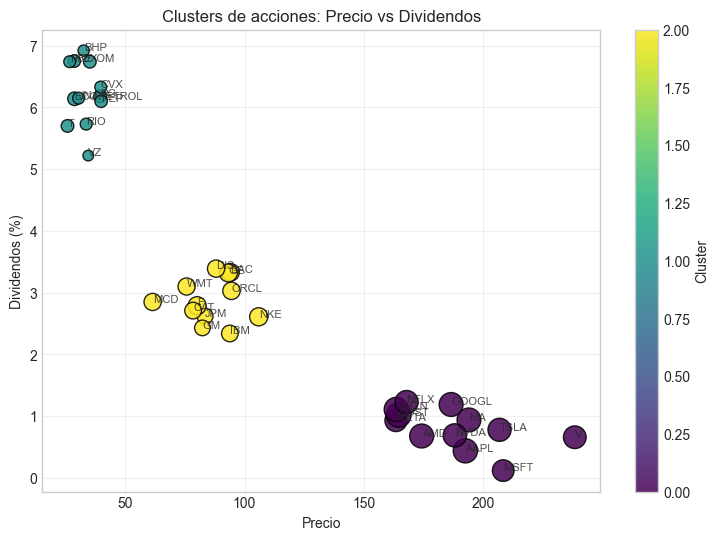

In [8]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df_cluster["Precio"],
    df_cluster["Dividendos"],
    c=df_cluster["Cluster"],
    s=df_cluster["Volatilidad"] * 6,
    cmap="viridis",
    alpha=0.85,
    edgecolor="black",
)

for _, row in df_cluster.iterrows():
    plt.annotate(row["Accion"], (row["Precio"], row["Dividendos"]), fontsize=8, alpha=0.8)

plt.xlabel("Precio")
plt.ylabel("Dividendos (%)")
plt.title("Clusters de acciones: Precio vs Dividendos")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()


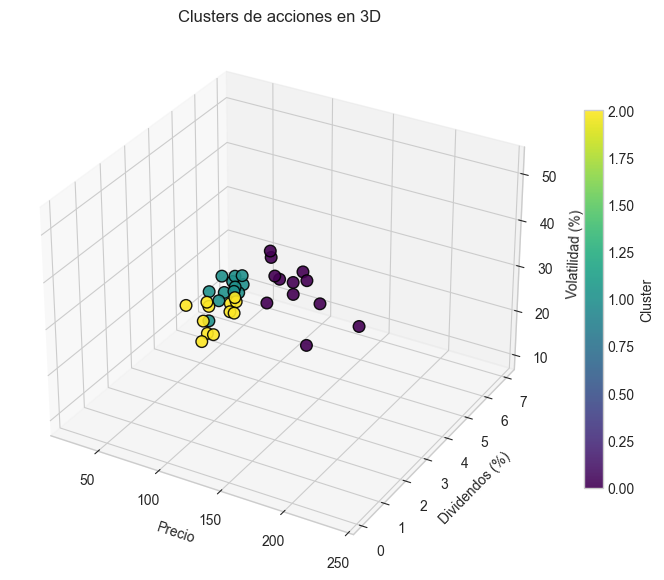

In [9]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_cluster["Precio"],
    df_cluster["Dividendos"],
    df_cluster["Volatilidad"],
    c=df_cluster["Cluster"],
    cmap="viridis",
    s=70,
    alpha=0.9,
    edgecolor="black",
)

ax.set_xlabel("Precio")
ax.set_ylabel("Dividendos (%)")
ax.set_zlabel("Volatilidad (%)")
ax.set_title("Clusters de acciones en 3D")
fig.colorbar(scatter, ax=ax, label="Cluster", shrink=0.7)
plt.show()


## 8. Grafico silhouette para K = 3

Este grafico permite ver la calidad del agrupamiento accion por accion. La linea roja marca el silhouette promedio del modelo final.


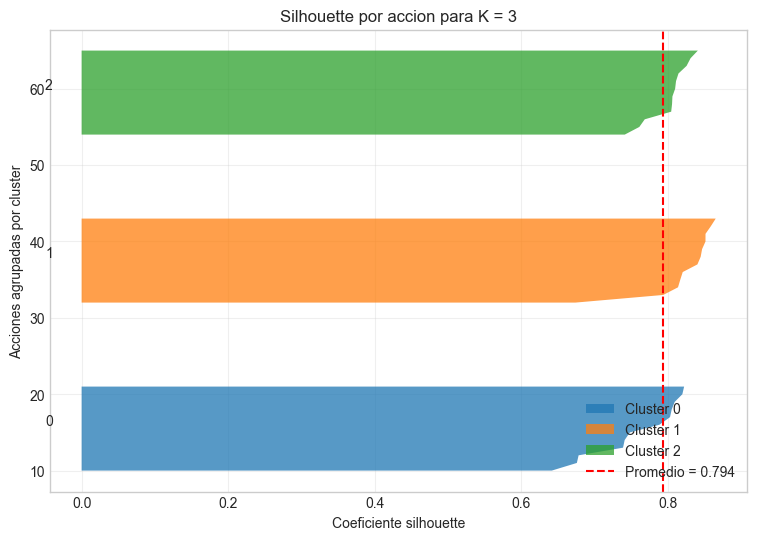

Silhouette promedio final con K = 3: 0.7936


In [10]:
labels = df_cluster["Cluster"].to_numpy()
silhouette_vals = silhouette_samples(X_scaled, labels)
silhouette_avg = silhouette_score(X_scaled, labels)

y_lower = 10
plt.figure(figsize=(9, 6))

for cluster in range(k_optimo):
    cluster_vals = silhouette_vals[labels == cluster]
    cluster_vals.sort()
    y_upper = y_lower + len(cluster_vals)

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_vals,
        alpha=0.75,
        label=f"Cluster {cluster}",
    )
    plt.text(-0.05, y_lower + 0.5 * len(cluster_vals), str(cluster))
    y_lower = y_upper + 10

plt.axvline(silhouette_avg, color="red", linestyle="--", label=f"Promedio = {silhouette_avg:.3f}")
plt.xlabel("Coeficiente silhouette")
plt.ylabel("Acciones agrupadas por cluster")
plt.title("Silhouette por accion para K = 3")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Silhouette promedio final con K = {k_optimo}: {silhouette_avg:.4f}")


## Conclusiones para la sustentacion

- El metodo del codo muestra una fuerte reduccion de la inercia hasta **K = 3**. Despues de ese punto, la mejora es menor.
- El coeficiente de silhouette permite validar la separacion entre grupos. En estos datos simulados, **K = 3** obtiene una separacion alta frente a otras opciones.
- K-means se aplico sobre variables estandarizadas para evitar que `Precio` domine la distancia.
- Los centroides se interpretan en la escala original para explicar los grupos de acciones:
  - acciones de crecimiento,
  - acciones balanceadas,
  - acciones defensivas o de dividendos.
